Object segmentation network

Data loader implementation

In [40]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import numpy as np

class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths, self.annotation_paths = self.collect_paths(root_dir)

    def collect_paths(self, root_dir):
        image_paths = []
        annotation_paths = []

        annotation_root = os.path.join(root_dir, "Annotations")
        image_root = os.path.join(root_dir, "Images")

        for subdir in os.listdir(annotation_root):
            annotation_subfolder = os.path.join(annotation_root, subdir)
            image_subfolder = os.path.join(image_root, subdir)

            if os.path.isdir(annotation_subfolder) and os.path.isdir(image_subfolder):
                for filename in os.listdir(annotation_subfolder):
                    if filename.endswith(".txt"):
                        annotation_path = os.path.join(annotation_subfolder, filename)
                        image_filename = os.path.splitext(filename)[0] + ".jpg"
                        image_path = os.path.join(image_subfolder, image_filename)
                        if os.path.exists(image_path):
                            annotation_paths.append(annotation_path)
                            image_paths.append(image_path)

        return image_paths, annotation_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        annotation_path = self.annotation_paths[idx]

        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)

        # Load and parse annotation (you'll need to implement this part based on the content of your annotation file)
        boxes = self.parse_annotation(annotation_path)
        boxes_array = np.array(boxes)
        # print(boxes_array)
        num_objs = len(boxes) 
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64) # suppose all instances are not crowd 
        if num_objs == 0:
            area = torch.tensor([ 0.0 ])
        else:
            area = (boxes_array[:, 3] - boxes_array[:, 1]) * (boxes_array[:, 2] - boxes_array[:, 0])
        target = {
            'boxes': boxes,
            # 'labels': torch.zeros(len(boxes), dtype=torch.int64)
            'labels': torch.ones(len(boxes), dtype=torch.int64), # for binary classification
            'image_id': torch.tensor([idx]),
            'area': area,
            'iscrowd': iscrowd
        }
        
        return image, target

    def parse_annotation(self, annotation_path):
        with open(annotation_path, 'r') as file:
            lines = file.readlines()

        num_objects = int(lines[0].strip())
        bounding_boxes = []

        for i in range(1, num_objects + 1):
            values = list(map(int, lines[i].strip().split()))
            if len(values) == 4:
                bounding_boxes.append(values)

        return bounding_boxes

Initialize the data loader

In [41]:
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define your data transformation (e.g., resizing, normalization, etc.)
transform = transforms.Compose([
    transforms.Resize((560, 480)),
    transforms.ToTensor(),
])

# Create an instance of the custom dataset
dataset = CustomDataset(root_dir='./data/TrainValid/TrainValid', transform=transform) # path is correct

# Create a DataLoader to iterate through the dataset
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

Test the data loader (re-run this cell to see different examples)

[tensor([299]), tensor([136]), tensor([559]), tensor([401])]


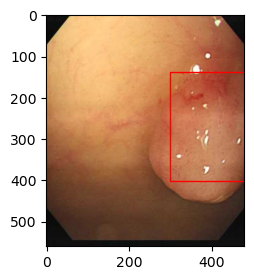

[tensor([103]), tensor([245]), tensor([224]), tensor([456])]


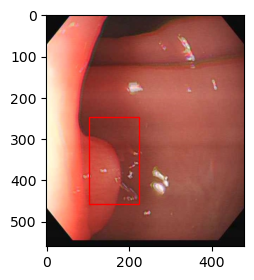

[tensor([146]), tensor([36]), tensor([419]), tensor([120])]


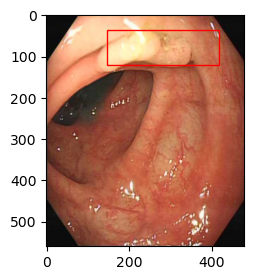

[tensor([294]), tensor([337]), tensor([352]), tensor([387])]


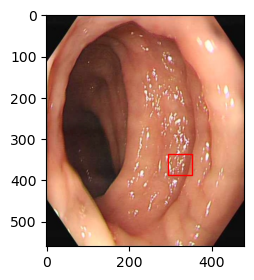

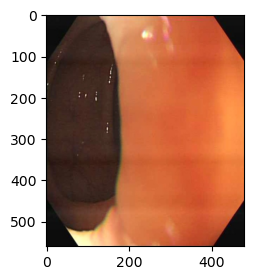

In [42]:
max_images_to_display = 5  # Set the maximum number of images to display
image_counter = 0    # Initialize a counter

# Set the desired figure size
fig_width, fig_height = 4, 3  # Adjust these values to your preference

# Test by iterating through the dataset
for image, target in dataloader:
    # Convert the PyTorch tensor to a NumPy array for visualization
    image = image.squeeze(0).permute(1, 2, 0).numpy()

    # Create a figure and axis
    fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))
    ax.imshow(image)
    
    bounding_boxes = target['boxes']
    # Iterate through bounding boxes and draw them on the image
    for box in bounding_boxes:
        print(box)
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

    # Show the image with bounding boxes
    plt.show()
    
    # Increment the image counter
    image_counter += 1

    if image_counter >= max_images_to_display:
        break  # Exit the loop after displaying the desired number of images

Select the device to train the model on (GPU by default if available)

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


Define the data collate function for the DataLoader (which combines multiple images into a batch)

In [44]:
from torchvision.transforms import ToTensor

# def collate_fn(batch):
#     print(batch)
#     images, annotations = zip(*batch)
# 
#     # Convert images to PIL Images
#     # images = [Image.fromarray(image) for image in images]
# 
#     # Apply the ToTensor transform to images to convert them to PyTorch tensors
#     images = [ToTensor()(image) for image in images]
# 
#     # Combine bounding box annotations into a single list
#     annotation_list = []
#     for annotation in annotations:
#         annotation_list.extend(annotation)
# 
#     return images, annotation_list


In [45]:
# def collate_fn(batch):
#     images = []
#     targets = []
# 
#     for img, annotation in batch:
#         images.append(img)
# 
#         num_boxes = annotation[0]
#         boxes = torch.tensor(annotation[1:], dtype=torch.float32).view(num_boxes, 4)
# 
#         # In your case, all objects belong to class 0 (Polyp), so create a tensor with all zeros for labels.
#         labels = torch.zeros(num_boxes, dtype=torch.int64)
# 
#         target = {
#             'boxes': boxes,
#             'labels': labels
#         }
# 
#         targets.append(target)
# 
#     return images, targets

Define the model

In [46]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import torchvision.transforms as T
import torch.optim as optim
import torchvision

# Split the dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2)

# Define the model
model = fasterrcnn_resnet50_fpn(weights=True)

model = model.to(device)

# Modify the model for your specific dataset: Change the number of classes
num_classes = 1 # 1 class (Polyp) + background
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Define the optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

Train the model

In [32]:
# For Training
images, targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images, targets)  # Returns losses and detections
print(output)

# For inference
model.eval()
x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
predictions = model(x)  # Returns predictions
print(predictions[0])


AttributeError: 'str' object has no attribute 'items'

In [17]:
# Train the model
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    for images, targets in train_loader:
        # images = list(transforms.ToPILImage()(image) for image in images)
        # targets = [{k: v for k, v in target.items()} for target in targets]
        
        # Move images and targets to device
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    # Update the learning rate
    lr_scheduler.step()

AttributeError: 'str' object has no attribute 'items'

In [63]:
# Save the trained model
torch.save(model.state_dict(), 'your_model.pth')


Saving the model

In [ ]:
from datetime import datetime

# Generate a timestamp or unique identifier
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define a directory to save the models
save_dir = "./saved_models/"

# Create the parent directory if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the generator model and optimizer state with a unique filename
generator_checkpoint_file = f"{save_dir}generator_checkpoint_{timestamp}.pth"
torch.save({
    'model_state_dict': netG.state_dict(),
    'optimizer_state_dict': optimizerG.state_dict()
}, generator_checkpoint_file)

# Save the discriminator model and optimizer state with a unique filename
discriminator_checkpoint_file = f"{save_dir}discriminator_checkpoint_{timestamp}.pth"
torch.save({
    'model_state_dict': netD.state_dict(),
    'optimizer_state_dict': optimizerD.state_dict()
}, discriminator_checkpoint_file)

# # Define filenames with timestamps
# g_losses_filename =  os.path.join(save_dir, f"g_losses_{timestamp}.txt")
# d_losses_filename = os.path.join(save_dir, f"d_losses_{timestamp}.txt")
# 
# # Save G_losses to a file with a timestamp
# with open(g_losses_filename, 'w') as file:
#     for loss in G_losses:
#         file.write(f"{loss}\n")
# 
# # Save D_losses to a file with a timestamp
# with open(d_losses_filename, 'w') as file:
#     for loss in D_losses:
#         file.write(f"{loss}\n")
# 


Loading the model

In [ ]:
# Provide the timestamp you want to load
specified_timestamp = "20231022200319"  # Replace with the desired timestamp

# Load the generator model and optimizer state
checkpoint = torch.load(f'./saved_models/generator_checkpoint_{specified_timestamp}.pth')
netG.load_state_dict(checkpoint['model_state_dict'])
optimizerG.load_state_dict(checkpoint['optimizer_state_dict'])

# Load the discriminator model and optimizer state
checkpoint = torch.load(f'./saved_models/discriminator_checkpoint_{specified_timestamp}.pth')
netD.load_state_dict(checkpoint['model_state_dict'])
optimizerD.load_state_dict(checkpoint['optimizer_state_dict'])

# # Define the filenames based on the specified timestamp
# specified_g_losses_filename = f"./saved_models/g_losses_{specified_timestamp}.txt"
# specified_d_losses_filename = f"./saved_models/d_losses_{specified_timestamp}.txt"

# # Define lists to store the loaded losses
# loaded_G_losses = []
# loaded_D_losses = []
# 
# # Load G_losses from the file with the specified timestamp
# with open(specified_g_losses_filename, 'r') as file:
#     for line in file:
#         loaded_G_losses.append(float(line.strip()))
# 
# # Load D_losses from the file with the specified timestamp
# with open(specified_d_losses_filename, 'r') as file:
#     for line in file:
#         loaded_D_losses.append(float(line.strip()))
# 
# G_losses = loaded_G_losses
# D_losses = loaded_D_losses
